--- Starting Income Parameter Generation ---
Loading file: E:\Projetos\ABMS-WP\includes\Tabela_consumidores_Itapua_com_setor_comportamento_e_renda.csv
Valid records for analysis: 12688
Low Income Limit (40%): R$ 2418.30
High Income Limit (Top 9%): R$ 5793.16
------------------------------
Regression Slope (m3/R$): 0.001947
Regression Intercept (m3): 6.66
GAMA Normalized Sensitivity (k): 0.00029213
------------------------------
Plot saved to: E:\Projetos\ABMS-WP\figuras\grafico_analise_renda.png
GAMA Parameters file generated: E:\Projetos\ABMS-WP\includes\parametros_renda_calculados.csv


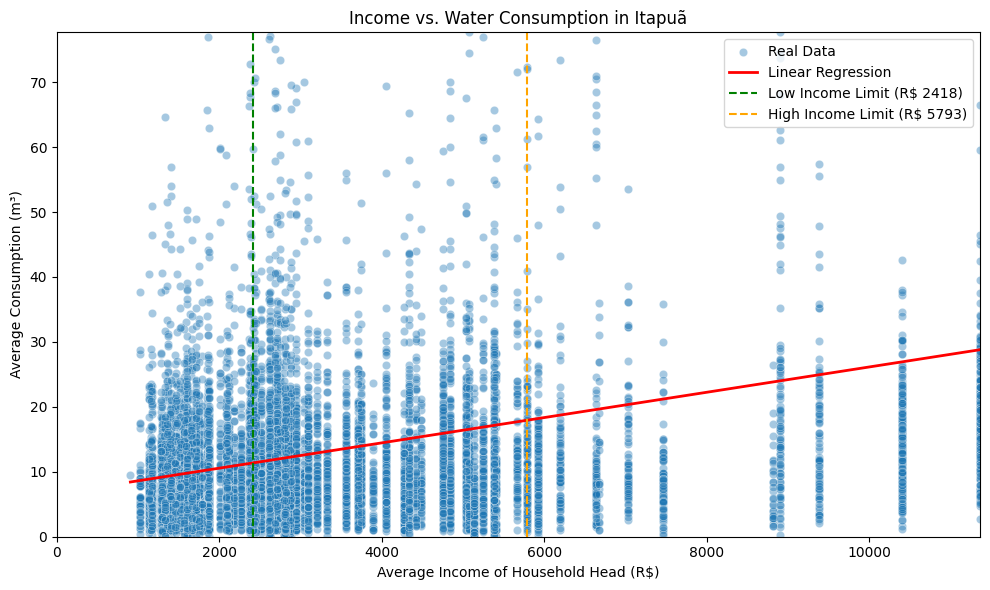

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. Configuration and Constants
# ==========================================

# Base Paths (Uncomment the active path)
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Input Filename
INPUT_FILENAME = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda.csv'

# Threshold Percentiles
LOW_INCOME_PERCENTILE = 0.40  # Bottom 40%
HIGH_INCOME_PERCENTILE = 0.90 # Top 10%

def load_and_clean_data(file_path):
    """
    Loads CSV data and handles decimal separators (comma/dot) standard issues.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # Load with flexible separators
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.')

    numeric_cols = ['VL_RENDA_MEDIA_RESPONSAVEL', 'NN_MEDIA_CONSUMO']

    for col in numeric_cols:
        # Force string conversion and replace comma with dot if necessary
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Remove invalid data (NaN or Zeros which distort regression)
    df_clean = df.dropna(subset=numeric_cols)
    df_clean = df_clean[(df_clean['VL_RENDA_MEDIA_RESPONSAVEL'] > 0) & (df_clean['NN_MEDIA_CONSUMO'] > 0)]

    return df_clean

def main():
    print("--- Starting Income Parameter Generation ---")

    # ==========================================
    # 2. Data Loading
    # ==========================================
    input_path = os.path.join(BASE_PATH, 'includes', INPUT_FILENAME)
    print(f"Loading file: {input_path}")
    
    df_clean = load_and_clean_data(input_path)
    print(f"Valid records for analysis: {len(df_clean)}")

    # ==========================================
    # 3. Limit Calculation (Percentiles)
    # ==========================================
    # Calculate income thresholds defining the social strata
    low_income_limit = df_clean['VL_RENDA_MEDIA_RESPONSAVEL'].quantile(LOW_INCOME_PERCENTILE)
    high_income_limit = df_clean['VL_RENDA_MEDIA_RESPONSAVEL'].quantile(HIGH_INCOME_PERCENTILE)

    print(f"Low Income Limit ({int(LOW_INCOME_PERCENTILE*100)}%): R$ {low_income_limit:.2f}")
    print(f"High Income Limit (Top {int((1-HIGH_INCOME_PERCENTILE)*100)}%): R$ {high_income_limit:.2f}")

    # ==========================================
    # 4. Sensitivity Calculation (Regression)
    # ==========================================
    # X = Income, y = Consumption
    X = df_clean[['VL_RENDA_MEDIA_RESPONSAVEL']].values
    y = df_clean['NN_MEDIA_CONSUMO'].values

    reg = LinearRegression()
    reg.fit(X, y)

    slope = reg.coef_[0]       # Slope (a): Increase in m3 for every R$ 1 of income
    intercept = reg.intercept_ # Intercept (b): Theoretical base consumption (Zero income)

    # --- NORMALIZED FACTOR CALCULATION FOR GAMA ---
    # The Linear Regression provides: y = b + a*x (Consumption = Intercept + Slope * Income)
    # The GAMA model uses the form:   y = b * (1 + k*x)
    # Expanding GAMA formula:         y = b + (b*k)*x
    # Therefore, equating terms:      Slope (a) = Intercept (b) * Factor (k)
    # Resulting Factor (k):           k = Slope / Intercept

    if intercept > 0:
        normalized_sensitivity = slope / intercept
    else:
        normalized_sensitivity = 0.0001 # Fallback to avoid division errors or negative base

    print("-" * 30)
    print(f"Regression Slope (m3/R$): {slope:.6f}")
    print(f"Regression Intercept (m3): {intercept:.2f}")
    print(f"GAMA Normalized Sensitivity (k): {normalized_sensitivity:.8f}")
    print("-" * 30)

    # ==========================================
    # 5. Plotting
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # Scatter plot of real data
    sns.scatterplot(x=df_clean['VL_RENDA_MEDIA_RESPONSAVEL'], y=df_clean['NN_MEDIA_CONSUMO'], alpha=0.4, label='Real Data')

    # Trend line
    x_range = np.linspace(df_clean['VL_RENDA_MEDIA_RESPONSAVEL'].min(), df_clean['VL_RENDA_MEDIA_RESPONSAVEL'].max(), 100)
    y_pred = intercept + slope * x_range
    plt.plot(x_range, y_pred, color='red', linewidth=2, label='Linear Regression')

    # Threshold lines
    plt.axvline(low_income_limit, color='green', linestyle='--', label=f'Low Income Limit (R$ {low_income_limit:.0f})')
    plt.axvline(high_income_limit, color='orange', linestyle='--', label=f'High Income Limit (R$ {high_income_limit:.0f})')

    plt.title('Income vs. Water Consumption in Itapuã')
    plt.xlabel('Average Income of Household Head (R$)')
    plt.ylabel('Average Consumption (m³)')
    
    # Trim extreme outliers for better visualization (99th percentile)
    plt.xlim(0, df_clean['VL_RENDA_MEDIA_RESPONSAVEL'].quantile(0.99)) 
    plt.ylim(0, df_clean['NN_MEDIA_CONSUMO'].quantile(0.99))
    
    plt.legend()
    plt.tight_layout()
    
    # --- SAVE PLOT TO 'RESULTADOS' FOLDER ---
    results_folder = os.path.join(BASE_PATH, 'resultados')
    picture_folder = os.path.join(BASE_PATH, 'figuras')
    # Create folder if it doesn't exist
    if not os.path.exists(results_folder):
        try:
            os.makedirs(results_folder)
            print(f"Directory created: {results_folder}")
        except OSError as e:
            print(f"Error creating directory: {e}")

    plot_output_path = os.path.join(picture_folder, 'grafico_analise_renda.png')
    plt.savefig(plot_output_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {plot_output_path}")

    # ==========================================
    # 6. Export Parameters for GAMA
    # ==========================================
    # IMPORTANT: The values in 'parametro' column are kept in Portuguese 
    # because the GAMA model (GAML) likely searches for these specific string keys.
    df_params = pd.DataFrame({
        'parametro': ['limite_baixa_renda', 'limite_alta_renda', 'sensibilidade_renda', 'intercepto_base'],
        'valor': [low_income_limit, high_income_limit, normalized_sensitivity, intercept]
    })

    # Save CSV parameters to 'includes' (usually where GAMA looks for inputs)
    csv_output_path = os.path.join(BASE_PATH, 'includes', 'parametros_renda_calculados.csv')
    df_params.to_csv(csv_output_path, sep=';', index=False)
    
    print(f"GAMA Parameters file generated: {csv_output_path}")

if __name__ == "__main__":
    main()